In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
import time


In [2]:
class CrashState(TypedDict):
  input : str
  s1 : str
  s2 : str
  s3 : str

In [3]:
def s1(state:CrashState):
  print('step 1 executed......')
  return {'s1':'done'}

def s2(state:CrashState):
  print('step2 hanging for 30 sec')
  time.sleep(30)
  return {'s2':'done'}


def s3(state:CrashState):
  print('step 2 executed....')
  return {'s3':'done'}

In [4]:
graph = StateGraph(CrashState)

graph.add_node('s1',s1)
graph.add_node('s2',s2)
graph.add_node('s3',s3)


graph.add_edge(START,'s1')
graph.add_edge('s1','s2')
graph.add_edge('s2','s3')
graph.add_edge('s3',END)

In [5]:
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

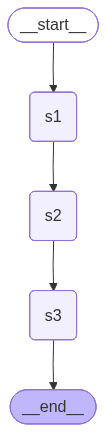

In [6]:
workflow

In [ ]:
try :
  print('work flow execution started...')
  config = {'configurable':{'thread_id':'1'}}
  workflow.invoke({'input':''},config=config)
except KeyboardInterrupt:
  print('execution stopped due to keyboaed interruption')